## Part A  – Dataset Understanding & Motivation 


* ### What the dataset represents (domain, context): 
    *   This dataset consists of four CSV files in the domain of global education and human development.It tracks the amount of education people receive in various countries and, in some files, how that education translates into actual learning through learning-adjusted years of schooling. The files collectively span several decades and numerous nations or areas, making it possible to analyze long-term trends like the growth of basic education, shifts in gender gaps, and distinctions between low- and high-income nations.
* ### Why it is interesting or useful: 
    * Because education has a significant impact on social mobility, health outcomes, and economic growth, monitoring these metrics over time aids in assessing a nation's progress and inequality. It is possible to examine how variables like enrollment, learning-adjusted years, and education spending move together, revealing patterns of advancement and stagnation across regions and income groups, thanks to the availability of multiple indicators per country-year. Since the data is split into four related tables, combining on shared keys such as country and year allows for a more comprehensive analysis leading to more insightful patterns than one table alone.
* ### Potential real-world or ML applications: 
    * In practice, this dataset can help with descriptive policy analysis by, for instance, identifying areas where learning and schooling outcomes fall short and measuring educational gaps based on gender or income. It can also be used for machine learning tasks like modeling how changes in spending or student-teacher ratios may impact future education outcomes, clustering countries into similar education profiles, and predicting learning-adjusted years of schooling from economic and demographic indicators.
* ### A link to the dataset source: 
    https://www.kaggle.com/datasets/imtkaggleteam/global-education
    


**Note:** in order to be able to reach the requirements of the assignment (>5000 & 15-20 attributes), I had to combine the four CSVs of the dataset and compute an extra feature. 

## Part B – Data Preprocessing & Cleaning 

### 5.1 Data Inspection


In [28]:

import pandas as pd

data = pd.read_csv("combined_dataset.csv")

# inspection of the datatypes and structure of the datasets
data.info() #doesnot need display() or print() because info() already prints the output to the console

display(data.head()) 
display(data.tail())

# inspecting the shapes of the datasets and their column names
display(data.shape, data.columns) # gap.shape => (entries, columns) gap.columns => list of column names in gap

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9945 entries, 0 to 9944
Data columns (total 20 columns):
 #   Column                                                                                              Non-Null Count  Dtype  
---  ------                                                                                              --------------  -----  
 0   Entity                                                                                              9945 non-null   object 
 1   Code                                                                                                8853 non-null   object 
 2   Year                                                                                                9945 non-null   int64  
 3   Share of population with no formal education, 1820-2020                                             468 non-null    float64
 4   Share of population with some formal education, 1820-2020                                           468 non-null  

,Entity,Code,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
0,Afghanistan,AFG,1820,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1820
1,Afghanistan,AFG,1825,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1820
2,Afghanistan,AFG,1830,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1830
3,Afghanistan,AFG,1835,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1830
4,Afghanistan,AFG,1840,NaN,NaN,0.0,0.01,0.01,0.0,0.0,0.01,NaN,NaN,NaN,0.01,0.01,0.01,NaN,0.01,1840


,Entity,Code,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
9940,Zimbabwe,ZWE,2015,4.0,96.0,9.17213,10.91966,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.74753,NaN,NaN,NaN,20.09179,2010
9941,Zimbabwe,ZWE,2016,NaN,NaN,8.54473,7.76729,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.77744,NaN,NaN,NaN,16.31202,2010
9942,Zimbabwe,ZWE,2017,NaN,NaN,9.68927,8.00596,NaN,NaN,NaN,NaN,NaN,NaN,6.35000,-1.68331,NaN,NaN,NaN,17.69523,2010
9943,Zimbabwe,ZWE,2018,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00661,NaN,NaN,NaN,NaN,NaN,2010
9944,Zimbabwe,ZWE,2020,3.0,97.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00661,NaN,NaN,NaN,NaN,NaN,2020


(9945, 20)

Index(['Entity', 'Code', 'Year',
       'Share of population with no formal education, 1820-2020',
       'Share of population with some formal education, 1820-2020',
       'Combined gross enrolment ratio for tertiary education, female',
       'Combined gross enrolment ratio for tertiary education, male',
       'Combined total net enrolment rate, secondary, male',
       'Combined total net enrolment rate, secondary, female',
       'Combined total net enrolment rate, primary, female',
       'Combined total net enrolment rate, primary, male',
       'Out-of-school children, adolescents and youth of primary and secondary school age, male (number)',
       'Out-of-school children, adolescents and youth of primary and secondary school age, female (number)',
       'Learning-Adjusted Years of School', 'tertiary_gender_gap',
       'secondary_gender_gap', 'primary_gender_gap', 'total_out_of_school',
       'total_tertiary_enrollment', 'decade'],
      dtype='object')

Initial summary statistics

In [30]:
print("\nStatistical Summary (Numerical):")
display(data.describe())

# 4. Statistical summary (All columns, including categorical)
print("\nStatistical Summary (All Columns):")
display(data.describe(include='all'))


Statistical Summary (Numerical):


,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
count,9945.000000,468.000000,468.000000,8251.000000,8251.000000,6538.000000,6538.000000,6855.000000,6855.000000,2.577000e+03,2.577000e+03,637.000000,8251.000000,6538.000000,6855.000000,2.574000e+03,8251.000000,9945.000000
mean,1962.159980,22.095108,77.904892,19.170464,16.506685,32.055344,31.498507,53.364914,59.137355,6.412909e+06,7.553630e+06,8.017871,-2.663780,0.556837,5.772440,1.398214e+07,35.677149,1958.472599
std,59.350235,28.451195,28.451195,27.995750,21.995645,35.751953,37.043541,38.688078,37.319553,2.314300e+07,2.773425e+07,2.547377,9.558125,5.908243,12.766902,5.083069e+07,49.434635,58.508633
min,1820.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.400000e+01,3.300000e+01,2.206502,-61.417130,-66.550000,-60.650000,1.650000e+02,0.000000,1820.000000
25%,1920.000000,1.000000,64.850000,0.000000,0.060000,0.140000,0.010000,6.920000,19.710000,1.476800e+04,1.150500e+04,6.024927,-3.296895,-1.123567,-0.010000,2.572000e+04,0.070000,1920.000000
50%,1991.000000,7.000000,93.000000,3.167690,5.653580,12.047725,6.580000,64.800030,74.000000,1.232130e+05,1.027850e+05,8.169077,0.010000,0.010000,1.100000,2.297905e+05,9.270000,1990.000000
75%,2008.000000,35.150000,99.000000,30.156035,27.061165,69.839107,72.712023,90.564715,93.026330,1.084688e+06,1.127516e+06,10.321753,1.110000,1.429128,8.803449,2.239783e+06,57.166905,2000.000000
max,2021.000000,98.200000,100.000000,152.656900,149.406390,100.000000,100.000000,100.000000,99.991820,1.734708e+08,2.121824e+08,12.937873,48.148030,72.520000,90.700000,3.816765e+08,301.809210,2020.000000



Statistical Summary (All Columns):


,Entity,Code,Year,"Share of population with no formal education, 1820-2020","Share of population with some formal education, 1820-2020","Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male","Out-of-school children, adolescents and youth of primary and secondary school age, male (number)","Out-of-school children, adolescents and youth of primary and secondary school age, female (number)",Learning-Adjusted Years of School,tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_out_of_school,total_tertiary_enrollment,decade
count,9945,8853,9945.000000,468.000000,468.000000,8251.000000,8251.000000,6538.000000,6538.000000,6855.000000,6855.000000,2.577000e+03,2.577000e+03,637.000000,8251.000000,6538.000000,6855.000000,2.574000e+03,8251.000000,9945.000000
unique,241,210,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,World,OWID_WRL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,81,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,1962.159980,22.095108,77.904892,19.170464,16.506685,32.055344,31.498507,53.364914,59.137355,6.412909e+06,7.553630e+06,8.017871,-2.663780,0.556837,5.772440,1.398214e+07,35.677149,1958.472599
std,NaN,NaN,59.350235,28.451195,28.451195,27.995750,21.995645,35.751953,37.043541,38.688078,37.319553,2.314300e+07,2.773425e+07,2.547377,9.558125,5.908243,12.766902,5.083069e+07,49.434635,58.508633
min,NaN,NaN,1820.000000,0.000000,1.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,1.400000e+01,3.300000e+01,2.206502,-61.417130,-66.550000,-60.650000,1.650000e+02,0.000000,1820.000000
25%,NaN,NaN,1920.000000,1.000000,64.850000,0.000000,0.060000,0.140000,0.010000,6.920000,19.710000,1.476800e+04,1.150500e+04,6.024927,-3.296895,-1.123567,-0.010000,2.572000e+04,0.070000,1920.000000
50%,NaN,NaN,1991.000000,7.000000,93.000000,3.167690,5.653580,12.047725,6.580000,64.800030,74.000000,1.232130e+05,1.027850e+05,8.169077,0.010000,0.010000,1.100000,2.297905e+05,9.270000,1990.000000
75%,NaN,NaN,2008.000000,35.150000,99.000000,30.156035,27.061165,69.839107,72.712023,90.564715,93.026330,1.084688e+06,1.127516e+06,10.321753,1.110000,1.429128,8.803449,2.239783e+06,57.166905,2000.000000


### 5.2 Handling Missing Data

Identifying missing values

In [143]:
missing = data.isnull().sum() #.isnull() returns a dataframe of the same shape as data with True for missing values and False for non-missing values, then sum() counts the number of True values in each column, which gives us the number of missing values per column
#by default, the data.isnull().sum() is per column, if we wanted to count missing values per row, we would use data.isnull().sum(axis=1)
display(missing) 
missing_percentage = (missing / len(data)) * 100
print(f"percentage of missing values in each column: {missing_percentage}")
print(f"number of duplicated rows: {data.duplicated().sum()}")


Entity                                                                                                   0
Code                                                                                                  1092
Year                                                                                                     0
Share of population with no formal education, 1820-2020                                               9477
Share of population with some formal education, 1820-2020                                             9477
Combined gross enrolment ratio for tertiary education, female                                         1694
Combined gross enrolment ratio for tertiary education, male                                           1694
Combined total net enrolment rate, secondary, male                                                    3407
Combined total net enrolment rate, secondary, female                                                  3407
Combined total net enrolment rate, pr

percentage of missing values in each column: Entity                                                                                                 0.000000
Code                                                                                                  10.980392
Year                                                                                                   0.000000
Share of population with no formal education, 1820-2020                                               95.294118
Share of population with some formal education, 1820-2020                                             95.294118
Combined gross enrolment ratio for tertiary education, female                                         17.033685
Combined gross enrolment ratio for tertiary education, male                                           17.033685
Combined total net enrolment rate, secondary, male                                                    34.258421
Combined total net enrolment rate, secondary, female       

Considering that there are a lot of missing values in my dataset, i decided to drop all features that have >70% missing values

In [144]:

cd = missing_percentage[missing_percentage > 70] # this is a tuple of column names and their missing percentage that are above the threshold
display(cd)
cols_drop = cd.index.tolist() # i want to get a list of the names of the colums cuz that is how i will drop them later, so i get the index of the tuple which is the column name and convert it to a list
print(f"dropping {len(cols_drop)} columns with >70% missing")
data_cleaned = data.drop(columns=cols_drop)

Share of population with no formal education, 1820-2020                                               95.294118
Share of population with some formal education, 1820-2020                                             95.294118
Out-of-school children, adolescents and youth of primary and secondary school age, male (number)      74.087481
Out-of-school children, adolescents and youth of primary and secondary school age, female (number)    74.087481
Learning-Adjusted Years of School                                                                     93.594771
total_out_of_school                                                                                   74.117647
dtype: float64

dropping 6 columns with >70% missing


Then, i want to look at missing values per rows, to determine whether to drop all rows with missing values or not

In [145]:

print(f"rows with NO missing values: {data_cleaned.dropna().shape[0]}") # dropna() drops all rows with any missing values, then shape[0] is the number of rows left
print(f"rows with ANY missing values: {data_cleaned.isnull().any(axis=1).sum()}") # when axis = 0, we are looking at columns, when axis = 1, we are looking at rows, so this counts how many rows have any missing values

rows with NO missing values: 4815
rows with ANY missing values: 5130


Since my dataset has a time-series nature, the best imputation technique would be forward-fill as per my research on this matter. educational metrics evolve slowly per time, and so by using the forward-fill method, it is a logical approximation of the missing values and shouldn't distort my values much. given that the percentages of the missing values per columns are huge, i cannot rely on the imputation techniques we studied such as the mean/median/mode imputation. 

In [146]:

data_cleaned = data_cleaned.sort_values(['Entity', 'Year'])
data_cleaned = data_cleaned.groupby('Entity', group_keys=False).apply(lambda x: x.ffill())

print("Missing after forward fill:")
print(data_cleaned.isnull().sum()/len(data_cleaned) * 100)


Missing after forward fill:
Entity                                                            0.000000
Code                                                             10.980392
Year                                                              0.000000
Combined gross enrolment ratio for tertiary education, female     6.153846
Combined gross enrolment ratio for tertiary education, male       6.153846
Combined total net enrolment rate, secondary, male               11.111111
Combined total net enrolment rate, secondary, female             11.111111
Combined total net enrolment rate, primary, female                7.833082
Combined total net enrolment rate, primary, male                  7.833082
tertiary_gender_gap                                               6.153846
secondary_gender_gap                                             11.111111
primary_gender_gap                                                7.833082
total_tertiary_enrollment                                         6.1538

/var/folders/00/nt69sw_952986_bg7n7jm2c80000gn/T/ipykernel_27780/3170434756.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_cleaned = data_cleaned.groupby('Entity', group_keys=False).apply(lambda x: x.ffill())
/var/folders/00/nt69sw_952986_bg7n7jm2c80000gn/T/ipykernel_27780/3170434756.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_cleaned = data_cleaned.groupby('Entity', group_keys=False).apply(lambda x: x.ffill())


Given that there still are missing values after the forward-fill, its worth investigating dropping all the rows with high missing values.

In [147]:
perc_missing_per_row = (data_cleaned.isnull().sum(axis=1) / data_cleaned.shape[1]) * 100 # this calculates the percentage of missing values in each row by counting the number of missing values in each row (data.isnull().sum(axis=1)) and dividing by the total number of columns (data.shape[1]) 
print(perc_missing_per_row.describe()) 

thresholds = [0, 10, 20, 30, 40, 50] ###
for threshold in thresholds:
    rows_kept = (perc_missing_per_row <= threshold).sum()
    print(f"Rows with ≤{threshold}% missing: {rows_kept} ({rows_kept/len(data_cleaned)*100:.1f}% of total)")



count    9945.000000
mean        6.602025
std        18.117002
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        78.571429
dtype: float64
Rows with ≤0% missing: 8086 (81.3% of total)
Rows with ≤10% missing: 8657 (87.0% of total)
Rows with ≤20% missing: 8657 (87.0% of total)
Rows with ≤30% missing: 9196 (92.5% of total)
Rows with ≤40% missing: 9196 (92.5% of total)
Rows with ≤50% missing: 9486 (95.4% of total)


In [141]:

data_cols = [col for col in data_cleaned.columns if col not in ['Entity', 'Code']] 
data_cleaned = data_cleaned.dropna(subset=data_cols)

# Check missing values in cleaned dataset
print("Remaining missing values:")
display(data_cleaned.isnull().sum())
display(data_cleaned.shape)

Remaining missing values:


Entity                                                             0
Code                                                             571
Year                                                               0
Combined gross enrolment ratio for tertiary education, female      0
Combined gross enrolment ratio for tertiary education, male        0
Combined total net enrolment rate, secondary, male                 0
Combined total net enrolment rate, secondary, female               0
Combined total net enrolment rate, primary, female                 0
Combined total net enrolment rate, primary, male                   0
tertiary_gender_gap                                                0
secondary_gender_gap                                               0
primary_gender_gap                                                 0
total_tertiary_enrollment                                          0
decade                                                             0
dtype: int64

(8657, 14)

### 5.3

In [149]:

print(f"number of duplicated rows : {data_cleaned.duplicated(subset=['Entity', 'Code', 'Year']).sum()}")

number of duplicated rows : 0


In [ ]:

# remove whitespace of entity and code columns 
data_cleaned['Entity'] = data_cleaned['Entity'].str.strip()
data_cleaned['Code'] = data_cleaned['Code'].str.strip().str.upper()

# check if Year is integer and whether it needs standardization
print(f"Year data type is: {data_cleaned['Year'].dtype}")



Year data type is: int64


In [161]:

from sklearn.preprocessing import StandardScaler

excluded_cols = ['Entity', 'Code', 'Year', 'decade']
cols_to_scale = [col for col in data_cleaned.select_dtypes(include=['float64', 'int64']).columns 
                          if col not in excluded_cols]

scaler = StandardScaler().set_output(transform="pandas")
data_cleaned[cols_to_scale] = scaler.fit_transform(data_cleaned[cols_to_scale])

In [169]:

display(data_cleaned.describe().round(2))
display(data_cleaned.head(10))


,Year,"Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male",tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_tertiary_enrollment,decade
count,9945.00,9333.00,9333.00,8840.00,8840.00,9166.00,9166.00,9333.00,8840.00,9166.00,9333.00,9945.00
mean,1962.16,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,1958.47
std,59.35,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,58.51
min,1820.00,-0.69,-0.77,-1.07,-1.00,-1.65,-1.88,-6.07,-9.24,-5.55,-0.73,1820.00
25%,1920.00,-0.69,-0.76,-1.04,-1.00,-1.04,-0.79,-0.06,-0.37,-0.43,-0.73,1920.00
50%,1991.00,-0.54,-0.45,-0.23,-0.34,0.51,0.53,0.27,-0.12,-0.35,-0.50,1990.00
75%,2008.00,0.36,0.44,1.02,1.06,0.86,0.80,0.41,0.20,0.20,0.40,2000.00
max,2021.00,4.86,6.20,1.78,1.74,1.03,0.95,5.23,9.81,7.27,5.51,2020.00


,Entity,Code,Year,"Combined gross enrolment ratio for tertiary education, female","Combined gross enrolment ratio for tertiary education, male","Combined total net enrolment rate, secondary, male","Combined total net enrolment rate, secondary, female","Combined total net enrolment rate, primary, female","Combined total net enrolment rate, primary, male",tertiary_gender_gap,secondary_gender_gap,primary_gender_gap,total_tertiary_enrollment,decade
0,Afghanistan,AFG,1820,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1820
1,Afghanistan,AFG,1825,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1820
2,Afghanistan,AFG,1830,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1830
3,Afghanistan,AFG,1835,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1830
4,Afghanistan,AFG,1840,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1840
5,Afghanistan,AFG,1845,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1840
6,Afghanistan,AFG,1850,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1850
7,Afghanistan,AFG,1855,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1850
8,Afghanistan,AFG,1860,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1860
9,Afghanistan,AFG,1865,-0.691291,-0.765212,-1.068125,-1.002222,-1.646567,-1.877031,0.267762,-0.123949,-0.411947,-0.732521,1860


In [172]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_distribution(data: pd.DataFrame, variable: str):
    """
    Plots a boxplot and histogram for a given variable to visualize its distribution.

    Args:
        data: The pandas DataFrame containing the data.
        variable: The name of the column (variable) to plot.
    """
    # Create a figure with two subplots that share the x-axis
    f, (ax_box, ax_hist) = plt.subplots(
        nrows=2, 
        sharex=True, 
        gridspec_kw={"height_ratios": (.15, .85)},
        figsize=(8, 6)
    )

    # Add a title for the entire figure
    f.suptitle(f"Distribution of '{variable}'", fontsize=16)

    # Create a boxplot on the top subplot
    sns.boxplot(x=data[variable], ax=ax_box)
    # Create a histogram on the bottom subplot
    sns.histplot(data=data, x=variable, ax=ax_hist, kde=True)

    plt.show()


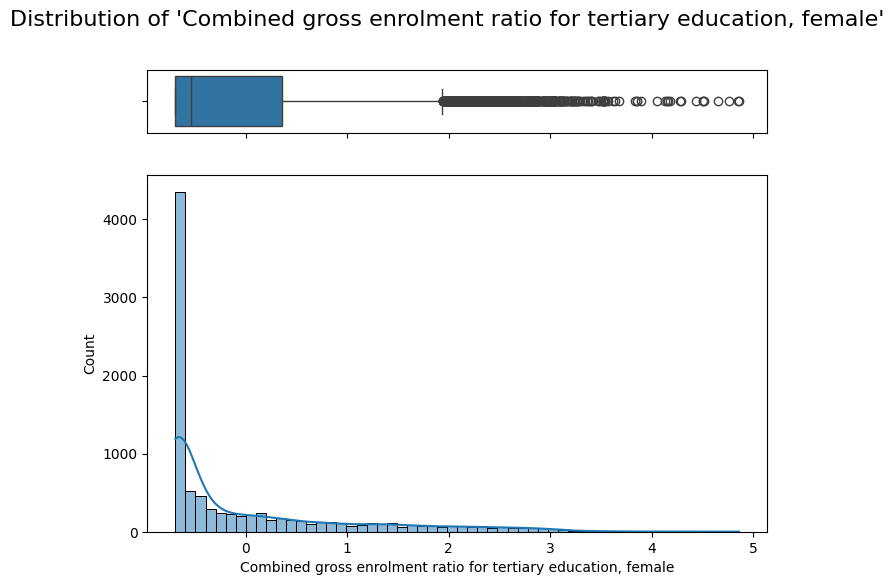

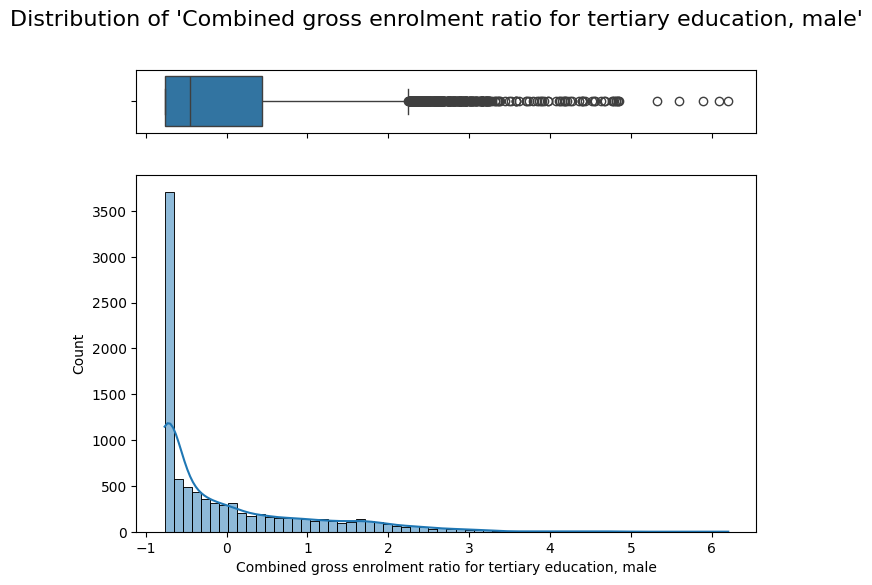

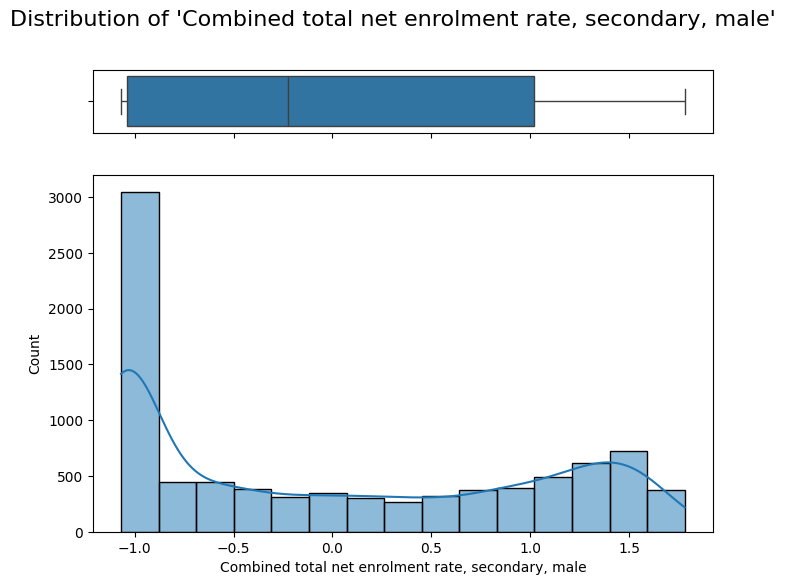

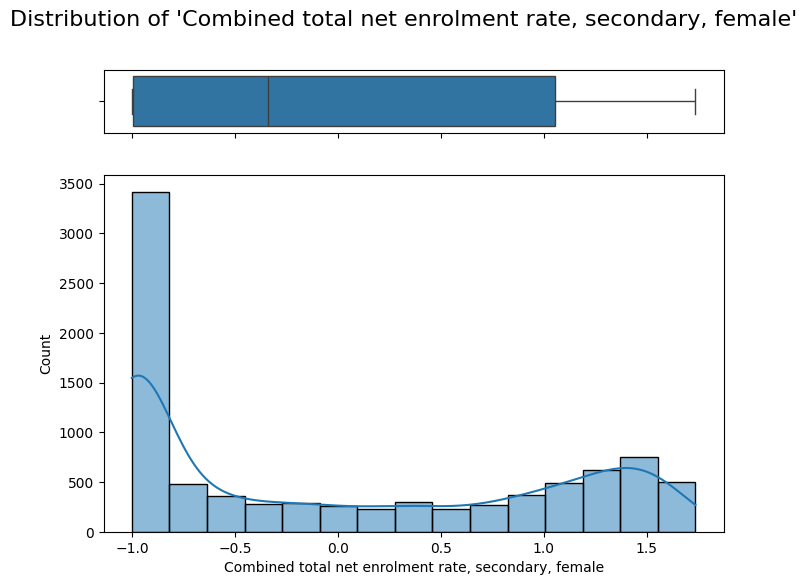

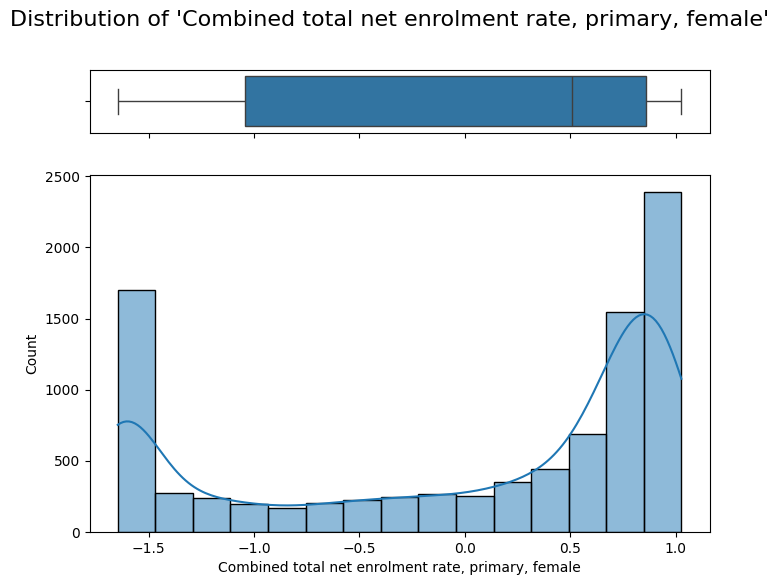

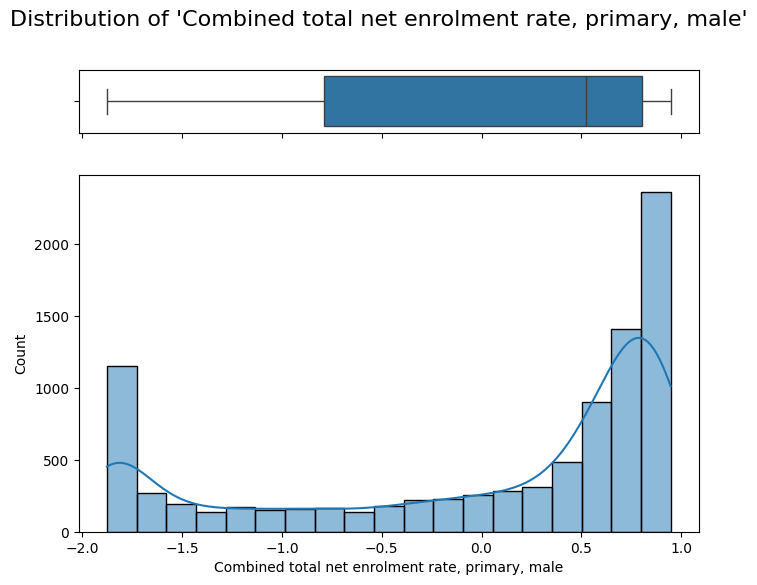

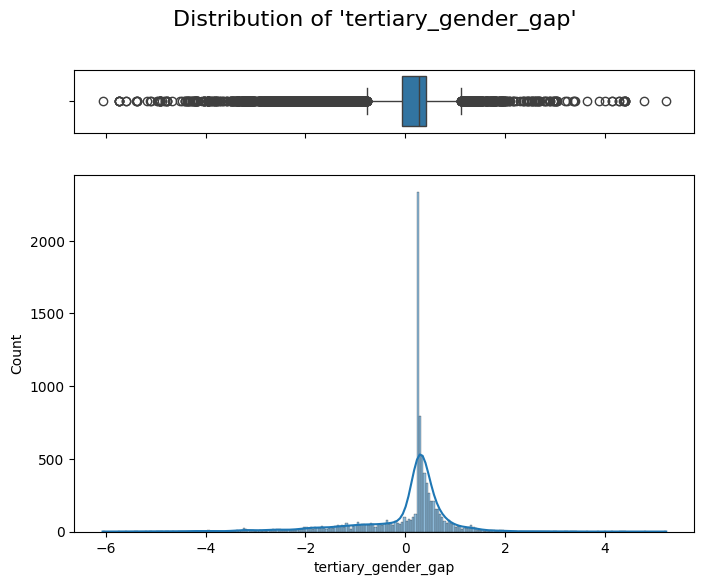

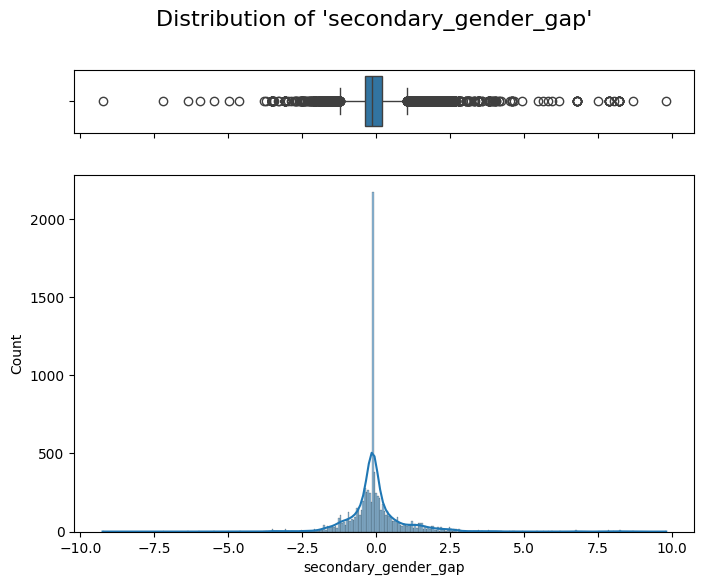

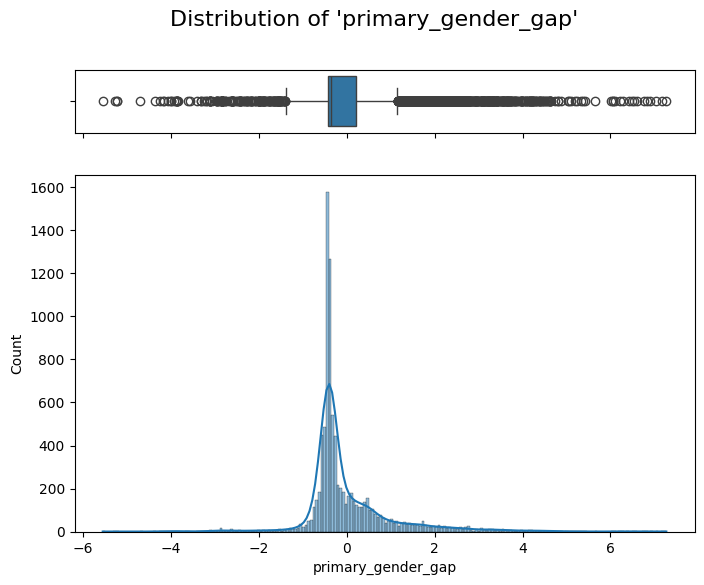

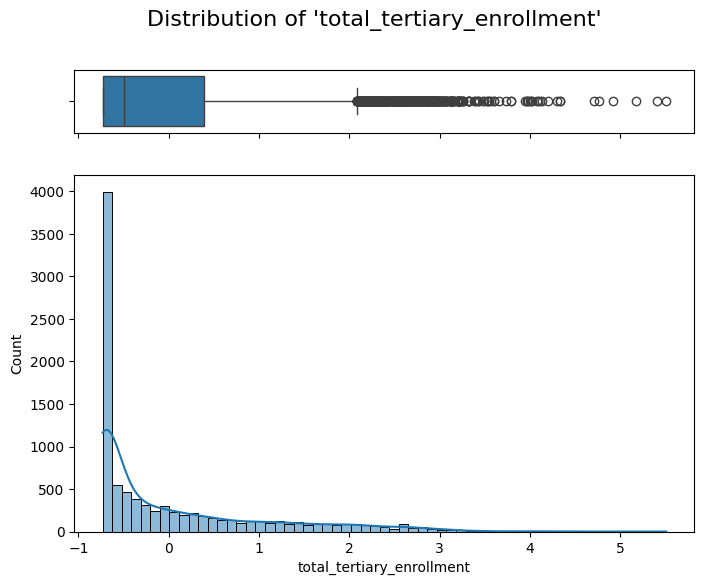

In [ ]:

for i in cols_to_scale:
    plot_distribution(data_cleaned, i)

In [180]:
def find_limits(df, variable, fold):

    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)

    lower_limit = df[variable].quantile(0.25) - (IQR * fold)
    upper_limit = df[variable].quantile(0.75) + (IQR * fold)

    return lower_limit, upper_limit

In [184]:
lower_limit, upper_limit = find_limits(data_cleaned, "Combined gross enrolment ratio for tertiary education, female", 1.5)
lower_limit, upper_limit

(np.float64(-2.270523204615333), np.float64(1.9417324320137834))